In [1]:
! pip install git+https://github.com/JamesRitchie/scikit-rvm.git -q

^C


In [ ]:
! pip install interpret -q

In [1]:
import pandas as pd
import numpy as np
import optuna
import warnings

from sklearn.metrics import median_absolute_error, mean_squared_error, make_scorer
from sklearn.model_selection import cross_val_score

from interpret.glassbox import ExplainableBoostingRegressor
from skrvm import RVR

warnings.filterwarnings('ignore')

In [2]:
data_dir = '../../data/processed/'

X_train = pd.read_csv(f'{data_dir}X_train_v2.csv')
y_train = pd.read_csv(f'{data_dir}y_train_v2.csv')

X_train_aug = pd.read_csv(f'{data_dir}X_train_augmented_v2.csv')
y_train_aug = pd.read_csv(f'{data_dir}y_train_augmented_v2.csv')

X_test = pd.read_csv(f'{data_dir}X_test_v2.csv')
y_test = pd.read_csv(f'{data_dir}y_test_v2.csv')

print(f"Orijinal Eğitim Seti Boyutu: {X_train.shape[0]} satır")
print(f"Çoğaltılmış Eğitim Seti Boyutu: {X_train_aug.shape[0]} satır")
print(f"Test Seti Boyutu: {X_test.shape[0]} satır")

Orijinal Eğitim Seti Boyutu: 413 satır
Çoğaltılmış Eğitim Seti Boyutu: 513 satır
Test Seti Boyutu: 104 satır


In [3]:
from IPython.display import display, clear_output
import gc
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np
from sklearn.metrics import median_absolute_error, mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import wilcoxon, spearmanr
import optuna
import seaborn as sns
import matplotlib.pyplot as plt

kf = KFold(n_splits=5, shuffle=True, random_state=42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

zero_fire_mask = (np.expm1(y_test).values.ravel() == 0)

if 'ALL_RESULTS' not in globals(): ALL_RESULTS = []
if 'FAMILY_SUMMARY' not in globals(): FAMILY_SUMMARY = {}

def calculate_metrics(y_true_log, y_pred_log):
    y_true_log = y_true_log.values.ravel() if isinstance(y_true_log, (pd.Series, pd.DataFrame)) else y_true_log
    
    y_true_ha = np.expm1(y_true_log)
    y_pred_ha = np.clip(np.expm1(y_pred_log), 0, None)
    
    medae = median_absolute_error(y_true_ha, y_pred_ha)
    mae = mean_absolute_error(y_true_ha, y_pred_ha)
    rmse = np.sqrt(mean_squared_error(y_true_ha, y_pred_ha))
    r2 = r2_score(y_true_log, y_pred_log) 
    
    spearman_corr, _ = spearmanr(y_true_ha, y_pred_ha)
    if np.isnan(spearman_corr): spearman_corr = 0.0
        
    zero_day_fp = np.sum(y_pred_ha[zero_fire_mask])
    
    return {
        'MedAE_ha': np.round(medae, 4),
        'MAE_ha': np.round(mae, 4),
        'RMSE_ha': np.round(rmse, 4),
        'R2': np.round(r2, 4),
        'Spearman': np.round(spearman_corr, 4),
        'Zero_FP_ha': np.round(zero_day_fp, 4)
    }

def style_dataframe(df):
    if df.empty: return df
    
    cm_error = sns.light_palette("#d35400", as_cmap=True) 
    cm_score = sns.light_palette("#2980b9", as_cmap=True) 
    
    styled_df = (df.style
        .background_gradient(subset=['MedAE_ha', 'MAE_ha', 'RMSE_ha', 'Zero_FP_ha'], cmap=cm_error)
        .background_gradient(subset=['R2', 'Spearman'], cmap=cm_score)
        .set_properties(**{
            'background-color': '#212529',
            'color': '#f8f9fa',
            'border': '1px solid #343a40',
            'text-align': 'center'
        })
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', '#f8f9fa'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '12px')]},
            {'selector': 'td', 'props': [('padding', '10px')]},
            {'selector': 'tr:hover', 'props': [('background-color', '#495057')]}
        ])
        .format(precision=4)
    )
    return styled_df

def plot_cumulative_bars():
    if not FAMILY_SUMMARY: return
    families = list(FAMILY_SUMMARY.keys())
    bests = [FAMILY_SUMMARY[f]['Best'] for f in families]
    means = [FAMILY_SUMMARY[f]['Mean'] for f in families]
    x = np.arange(len(families))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    color_best = '#A8E6CF' 
    color_mean = '#FFD3B6' 
    
    rects1 = ax.bar(x - width/2, bests, width, label='Best MedAE (ha)', color=color_best, edgecolor='#7f8c8d')
    rects2 = ax.bar(x + width/2, means, width, label='Mean MedAE (ha)', color=color_mean, edgecolor='#7f8c8d')
    
    ax.set_ylabel('Median Absolute Error (Hectares)', fontsize=11)
    ax.set_title('Cumulative Performance Across Model Families', fontsize=14, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(families, rotation=25, ha='right', fontsize=10)
    
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    
    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

def evaluate_model_family(family_name, models_dict):
    family_results = []
    wilcoxon_results = []
    total_models = len(models_dict)
    
    for idx, (model_name, config) in enumerate(models_dict.items(), 1):
        base_model_func = config['model']
        optuna_objective = config.get('objective', None)
        n_trials = config.get('n_trials', 30)
        timeout = config.get('timeout', 1800)
        
        preds_n_opt, preds_a_opt = None, None
        stages = ["Normal Data (Default)", "Normal Data (Optuna HPO)", "Augmented Data (Default)", "Augmented Data (Optuna HPO)"]
        
        for step, stage_name in enumerate(stages, 1):
            clear_output(wait=True)
            print(f"Evaluation Phase: {family_name}")
            print(f"Progress: [{idx}/{total_models}] Models Completed.")
            print(f"Currently Processing: {model_name} | Sub-routine {step}/4: {stage_name}")
            print("-" * 60)
            
            if family_results:
                display(style_dataframe(pd.DataFrame(family_results)))
            
            data_type = "Normal" if "Normal" in stage_name else "Augmented"
            config_type = "HPO" if "HPO" in stage_name else "Default"
            
            try:
                if config_type == "Default":
                    model = base_model_func()
                    if data_type == "Normal": model.fit(X_train, y_train.values.ravel())
                    else: model.fit(X_train_aug, y_train_aug.values.ravel())
                    preds = model.predict(X_test)
                else:
                    if not optuna_objective: continue
                    study = optuna.create_study(direction="minimize")
                    if data_type == "Normal":
                        study.optimize(lambda trial: optuna_objective(trial, X_train, y_train, kf), n_trials=n_trials, timeout=timeout)
                        best_model = base_model_func(**study.best_params)
                        best_model.fit(X_train, y_train.values.ravel())
                    else:
                        study.optimize(lambda trial: optuna_objective(trial, X_train_aug, y_train_aug, kf), n_trials=n_trials, timeout=timeout)
                        best_model = base_model_func(**study.best_params)
                        best_model.fit(X_train_aug, y_train_aug.values.ravel())
                        
                    preds = best_model.predict(X_test)
                    if data_type == "Normal": preds_n_opt = preds
                    else: preds_a_opt = preds
                
                metrics = calculate_metrics(y_test, preds)
                family_results.append({'Model': model_name, 'Data': data_type, 'Config': config_type, **metrics})
            except Exception as e:
                pass 
                
        if preds_n_opt is not None and preds_a_opt is not None:
            try:
                err_n = np.abs(np.expm1(y_test.values.ravel()) - np.clip(np.expm1(preds_n_opt), 0, None))
                err_a = np.abs(np.expm1(y_test.values.ravel()) - np.clip(np.expm1(preds_a_opt), 0, None))
                stat, p_val = wilcoxon(err_n, err_a)
                significance = "Significant" if p_val < 0.05 else "Not Significant"
                wilcoxon_results.append({'Model': model_name, 'Wilcoxon_p_value': p_val, 'Result': significance})
            except Exception:
                pass
                
        gc.collect()

    clear_output(wait=True)
    df_family = pd.DataFrame(family_results)
    ALL_RESULTS.append(df_family)
    
    print(f"Final Evaluation Complete: {family_name}")
    print("-" * 60)
    display(style_dataframe(df_family))
    
    if wilcoxon_results:
        print("\nStatistical Significance Testing (Normal vs Augmented):")
        df_wilcoxon = pd.DataFrame(wilcoxon_results)
        display(df_wilcoxon.style.set_properties(**{'background-color': '#212529', 'color': '#f8f9fa', 'border': '1px solid #343a40', 'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('background-color', '#343a40'), ('color', '#f8f9fa'), ('text-align', 'center')]}]))

    if not df_family.empty:
        best_medae = df_family['MedAE_ha'].min()
        mean_medae = df_family['MedAE_ha'].mean()
        FAMILY_SUMMARY[family_name] = {'Best': best_medae, 'Mean': mean_medae}
        plot_cumulative_bars()

print("Engine initialized. (Ready for EBM and RVM!)")

Engine initialized. (Ready for EBM and RVM!)


## HÜCRE 4: EBM (Explainable Boosting Machine) TESTLERİ

Final Evaluation Complete: Explainable Boosting Machine
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,Explainable Boosting Machine,Normal,Default,2.1331,19.9186,109.7373,0.0365,0.1989,96.8667
1,Explainable Boosting Machine,Normal,HPO,2.1342,19.9101,109.7554,0.0361,0.2189,93.3227
2,Explainable Boosting Machine,Augmented,Default,2.4578,19.9439,109.3946,0.0000,0.1140,128.1286
3,Explainable Boosting Machine,Augmented,HPO,2.4509,19.9762,109.3783,-0.0032,0.1056,127.1704



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,Explainable Boosting Machine,0.663899,Not Significant


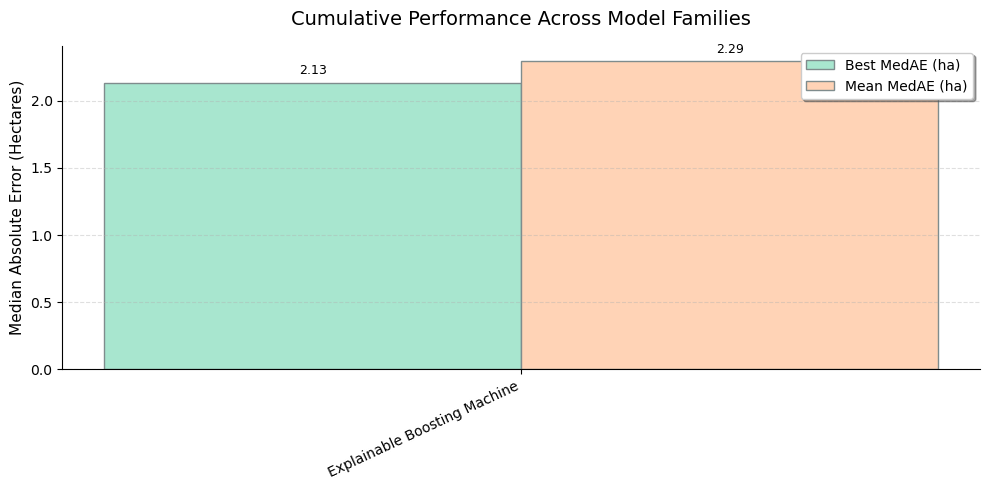

In [4]:
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.metrics import median_absolute_error, make_scorer
from sklearn.model_selection import cross_val_score

medae_scorer = make_scorer(median_absolute_error, greater_is_better=False)

def create_ebm(**kwargs):

    return ExplainableBoostingRegressor(random_state=42, outer_bags=4, interactions=2, **kwargs)

def objective_ebm(trial, X, y, cv):

    max_bins = trial.suggest_int('max_bins', 32, 256)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.1, log=True)
    
    model = create_ebm(max_bins=max_bins, learning_rate=learning_rate)
    return -cross_val_score(model, X, y.values.ravel(), cv=cv, scoring=medae_scorer).mean()

ebm_models = {
    'Explainable Boosting Machine': {
        'model': lambda **kwargs: create_ebm(**kwargs),
        'objective': objective_ebm,
        'n_trials': 15 
    }
}

evaluate_model_family("Explainable Boosting Machine", ebm_models)

## RVM (Relevance Vector Machine)

Final Evaluation Complete: Relevance Vector Machine
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,Relevance Vector Machine,Normal,Default,1.3262,19.7862,110.0763,-0.3037,0.2141,21.4923
1,Relevance Vector Machine,Normal,HPO,0.9726,19.7931,110.0141,-0.1494,0.0435,37.0938
2,Relevance Vector Machine,Augmented,Default,0.9457,19.7978,110.0025,-0.1278,0.1022,40.3935
3,Relevance Vector Machine,Augmented,HPO,1.0913,19.8493,109.9182,-0.0241,0.1822,65.0092



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,Relevance Vector Machine,0.958202,Not Significant


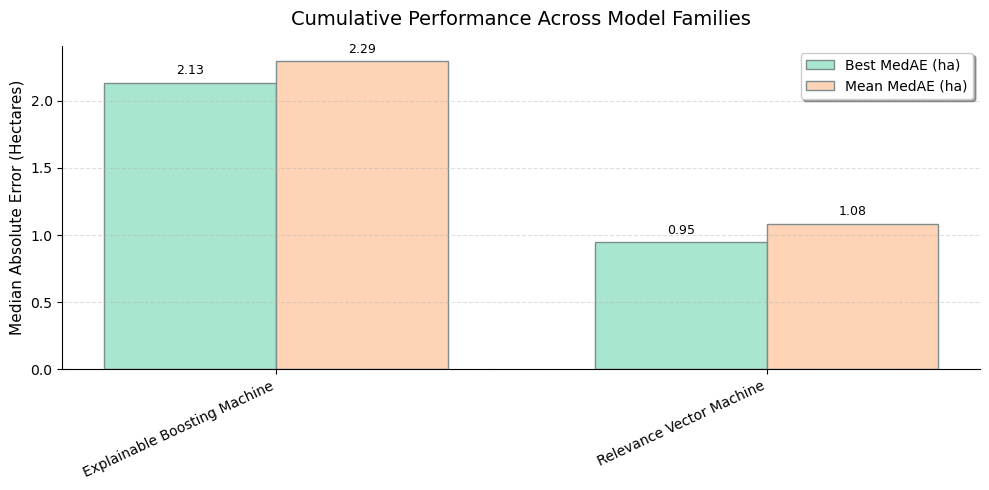

In [9]:
from skrvm import RVR
from sklearn.metrics import median_absolute_error

def create_rvm(**kwargs):
    return RVR(kernel='rbf', n_iter=150, tol=1e-2, **kwargs)
def objective_rvm(trial, X, y, cv):
    alpha = trial.suggest_float('alpha', 1e-8, 1e-3, log=True)
    beta = trial.suggest_float('beta', 1e-8, 1e-3, log=True)
    
    X_arr = X.values if hasattr(X, 'values') else X
    y_arr = y.values.ravel() if hasattr(y, 'values') else y.ravel()
    
    scores = []
    for train_idx, val_idx in cv.split(X_arr):
        X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
        y_tr, y_val = y_arr[train_idx], y_arr[val_idx]
        
        model = create_rvm(alpha=alpha, beta=beta)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        
        scores.append(median_absolute_error(y_val, preds))
        
    return np.mean(scores)

rvm_models = {
    'Relevance Vector Machine': {
        'model': lambda **kwargs: create_rvm(**kwargs),
        'objective': objective_rvm,
        'n_trials': 15 
    }
}

evaluate_model_family("Relevance Vector Machine", rvm_models)

### ==============================================================================
# TARGET TRANSFORMATION
## (Log(y+1) vs Tweedie vs Gamma Kıyaslaması ve Yüksek Performanslı Modeller)
### ==============================================================================
* **Amaç:** 0.42 MedAE rekorunu kırmak için SVR, RVM, RegMLP, Quantile GBM ve Yandex NODE modellerinin farklı matematiksel hedef uzaylarında (Log, Tweedie, Gamma) test edilmesi.
* **Test Mimarisi:** Modellerin sıfırlara karşı zafiyetini (Zero_FP_ha) ölçmek için, geçici maskelemeler kullanılarak sıfırlı ve sıfırsız eğitim verileriyle çapraz analiz yapılacaktır. Test seti her zaman adil kalmak adına orijinal bırakılmıştır.

In [11]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR
from skrvm import RVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import median_absolute_error, mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import KFold, cross_val_score
import optuna
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

optuna.logging.set_verbosity(optuna.logging.WARNING)
medae_scorer = make_scorer(median_absolute_error, greater_is_better=False)

data_dir = '../../data/processed/'
X_train = pd.read_csv(f"{data_dir}X_train_v2.csv")
y_train_v2 = pd.read_csv(f"{data_dir}y_train_v2.csv") 
X_test = pd.read_csv(f"{data_dir}X_test_v2.csv")
y_test = pd.read_csv(f"{data_dir}y_test_v2.csv")

mask_train = (y_train_v2['area'] > 0).values

X_train_nozero = X_train[mask_train].copy()
y_train_nozero = y_train_v2[mask_train].copy()

datasets_dict = {
    "Tüm Veri": (X_train, y_train_v2),
    "Sıfırsız Veri": (X_train_nozero, y_train_nozero)
}

print(f"Veriler Yüklendi! Test Seti (Orijinal Sabit): {X_test.shape[0]} satır.")
print(f"Tüm Veri Eğitim Seti (Log Uzayı): {X_train.shape[0]} satır.")
print(f"Sıfırsız Eğitim Seti (Log Uzayı): {X_train_nozero.shape[0]} satır.")

Veriler Yüklendi! Test Seti (Orijinal Sabit): 104 satır.
Tüm Veri Eğitim Seti (Log Uzayı): 413 satır.
Sıfırsız Eğitim Seti (Log Uzayı): 215 satır.


In [19]:
def calculate_metrics(y_true_log, y_pred_log):
    y_true_ha = np.expm1(y_true_log)
    y_pred_ha = np.clip(np.expm1(y_pred_log), 0, None)
    
    medae = median_absolute_error(y_true_ha, y_pred_ha)
    mae = mean_absolute_error(y_true_ha, y_pred_ha)
    rmse = np.sqrt(mean_squared_error(y_true_ha, y_pred_ha))
    r2 = r2_score(y_true_log, y_pred_log) 
    
    from scipy.stats import spearmanr
    spearman_corr, _ = spearmanr(y_true_log, y_pred_log)
    
    zero_mask = (y_true_ha.ravel() == 0)
    zero_fp = y_pred_ha[zero_mask].mean() if zero_mask.sum() > 0 else 0
    
    return {
        'MedAE_ha': medae, 'MAE_ha': mae, 'RMSE_ha': rmse,
        'R2': r2, 'Spearman': spearman_corr, 'Zero_FP_ha': zero_fp
    }

def plot_cumulative_bars(family_results, title="Model Kıyaslaması (Tüm Veri vs Sıfırsız Veri)"):
    if not family_results:
        return
    
    df = pd.DataFrame(family_results)
    pivot_df = df.pivot_table(index='Model', columns='Data', values='MedAE_ha', aggfunc='min')
    
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor('#1e1e1e')
    ax.set_facecolor('#1e1e1e')
    
    x = np.arange(len(pivot_df.index))
    columns = pivot_df.columns
    n_cols = len(columns)
    width = 0.35 if n_cols == 2 else 0.2
    
    colors = ['#00ffcc', '#ff6b6b', '#b19cd9']
    
    for i, col in enumerate(columns):
        offset = (i - n_cols/2 + 0.5) * width
        bars = ax.bar(x + offset, pivot_df[col], width, label=str(col), color=colors[i%len(colors)], edgecolor='#ffffff', linewidth=1)
        
        for container in bars:
            height = container.get_height()
            # EĞER MODEL ÇÖKMÜŞSE (NaN ise) YAZI YAZMA VE ATLA
            if pd.isna(height) or np.isnan(height):
                continue
                
            display_height = min(height, 12) 
            ax.annotate(f'{height:.2f}',
                        xy=(container.get_x() + container.get_width() / 2, display_height),
                        xytext=(0, 5),  
                        textcoords="offset points",
                        ha='center', va='bottom', color='#ffffff', fontsize=11, fontweight='bold')
            
    ax.set_ylabel('Median Absolute Error (Hectare)', color='#f0f0f0', fontsize=13, fontweight='bold')
    ax.set_title(title, color='#ffffff', fontsize=16, pad=25, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_df.index, rotation=15, ha='right', color='#f0f0f0', fontsize=12)
    ax.tick_params(axis='y', colors='#f0f0f0', labelsize=11)
    
    ax.grid(True, axis='y', linestyle='--', alpha=0.15, color='#ffffff')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#888888')
    ax.spines['left'].set_color('#888888')
    
    max_val = np.nanmax(pivot_df.values)
    max_limit = min(max_val * 1.1, 15)
    ax.set_ylim(0, max_limit)
    
    ax.legend(loc='upper right', frameon=True, facecolor='#2b2b2b', edgecolor='#444444', labelcolor='white', fontsize=11)
    plt.tight_layout()
    plt.show()

def evaluate_model_family(family_name, models_dict, datasets, X_tst, y_tst, timeout=300):
    family_results = []
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    for model_name, model_info in models_dict.items():
        base_model_func = model_info['model']
        optuna_objective = model_info.get('objective', None)
        n_trials = model_info.get('n_trials', 15)
        
        for data_type, (X_tr, y_tr) in datasets.items():
            for config_type in ["Default", "HPO"]:
                try:
                    if config_type == "Default":
                        model = base_model_func()
                        model.fit(X_tr, y_tr.values.ravel())
                        best_model = model
                    else:
                        if not optuna_objective: continue
                        study = optuna.create_study(direction="minimize")
                        study.optimize(lambda trial: optuna_objective(trial, X_tr, y_tr, kf), n_trials=n_trials, timeout=timeout)
                        best_model = base_model_func(**study.best_params)
                        best_model.fit(X_tr, y_tr.values.ravel())
                        
                    preds = best_model.predict(X_tst)
                    metrics = calculate_metrics(y_tst.values.ravel(), preds)
                    
                    result_row = {
                        'Model': model_name,
                        'Data': data_type,
                        'Config': config_type,
                        **metrics
                    }
                    family_results.append(result_row)
                except Exception as e:

                    pass
                
    clear_output(wait=True)
    print(f"\nFinal Evaluation Complete: {family_name}")
    print("-" * 80 + "\n")
    
    if family_results:
        df_results = pd.DataFrame(family_results)
        
        styled_df = df_results.style.format({
            'MedAE_ha': '{:.4f}', 'MAE_ha': '{:.4f}', 'RMSE_ha': '{:.4f}', 
            'R2': '{:.4f}', 'Spearman': '{:.4f}', 'Zero_FP_ha': '{:.4f}'
        }).set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#1e1e1e'), ('color', '#00ffcc'), ('border', '1px solid #444'), ('text-align', 'center'), ('font-size', '14px'), ('padding', '8px')]},
            {'selector': 'td', 'props': [('background-color', '#2b2b2b'), ('color', '#f0f0f0'), ('border', '1px solid #444'), ('text-align', 'center'), ('font-size', '13px'), ('padding', '8px')]},
            {'selector': 'tr:hover td', 'props': [('background-color', '#3a3a3a'), ('color', '#ffffff')]}
        ])
        display(styled_df)
        
        plot_cumulative_bars(family_results, title=f"{family_name} Performans Kıyaslaması")
    else:
        print("Uyarı: Hiçbir model başarıyla test edilemedi.")
        
    return family_results

## HÜCRE 3: AŞAMA 1 - LOG UZAYI


Final Evaluation Complete: Aşama 1: Temel Çizgi (Log Uzayı)
--------------------------------------------------------------------------------



,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,SVM,Tüm Veri,Default,0.7503,19.8733,110.0741,-0.2610,0.0137,0.5257
1,SVM,Sıfırsız Veri,Default,5.6502,21.4729,109.3392,-0.3031,-0.0798,6.0651
2,RVM,Tüm Veri,Default,1.3262,19.7862,110.0763,-0.3037,0.2137,0.4386
3,RVM,Sıfırsız Veri,Default,5.9350,21.4414,109.1675,-0.2999,-0.0698,6.3506
4,RegMLP (PyTorch Custom),Tüm Veri,Default,2.9828,20.2460,109.5672,-0.0267,0.1422,3.1531
5,RegMLP (PyTorch Custom),Sıfırsız Veri,Default,133.5991,1700.3918,7309.5020,-7.9273,0.0816,1787.7957
6,Yandex NODE,Tüm Veri,Default,0.6080,19.9004,110.1619,-0.4844,0.2292,0.1437


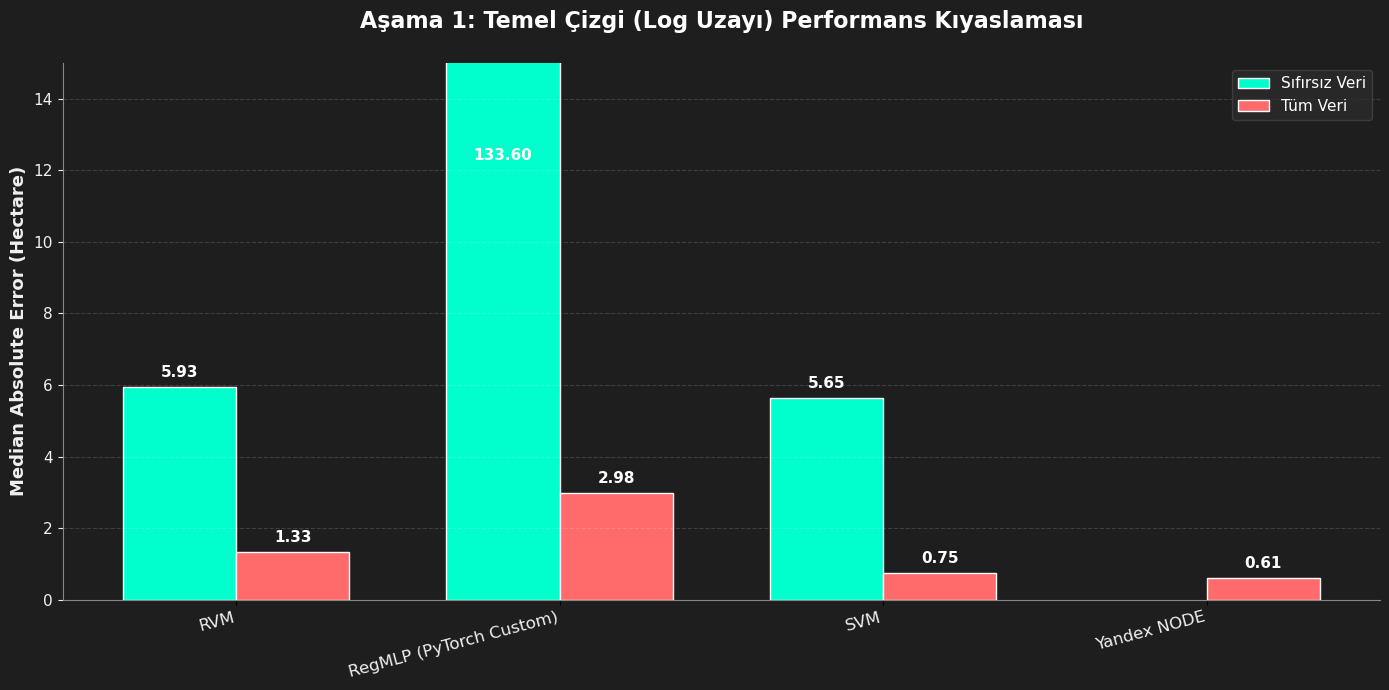

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.svm import SVR
from skrvm import RVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("pytorch_tabular").setLevel(logging.ERROR)
logging.getLogger("pytorch_tabular.models.node.node_model").setLevel(logging.ERROR) 

from pytorch_tabular import TabularModel
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig

class LogCoshLoss(nn.Module):
    def forward(self, y_pred, y_true):
        x = y_pred - y_true
        return torch.mean(x + torch.nn.functional.softplus(-2.0 * x) - np.log(2.))

class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, regularize=False):
        super().__init__()
        if not regularize:
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim//2), nn.ReLU(),
                nn.Linear(hidden_dim//2, 1)
            )
        else:
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(hidden_dim, hidden_dim//2), nn.BatchNorm1d(hidden_dim//2), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(hidden_dim//2, 1)
            )
    def forward(self, x):
        return self.net(x)

class PyTorchMLPWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, hidden_dim=64, regularize=False, epochs=150, lr=1e-3):
        self.hidden_dim = hidden_dim
        self.regularize = regularize
        self.epochs = epochs
        self.lr = lr
        self.model = None

    def fit(self, X, y):
        X_t = torch.tensor(X if not hasattr(X, 'values') else X.values, dtype=torch.float32)
        y_t = torch.tensor(y if not hasattr(y, 'values') else y.values, dtype=torch.float32).view(-1, 1)
        self.model = MLPNet(input_dim=X_t.shape[1], hidden_dim=self.hidden_dim, regularize=self.regularize)
        criterion = LogCoshLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        
        self.model.train()
        for epoch in range(self.epochs):
            optimizer.zero_grad()
            preds = self.model(X_t)
            loss = criterion(preds, y_t)
            loss.backward()
            optimizer.step()
        return self

    def predict(self, X):
        self.model.eval()
        X_t = torch.tensor(X if not hasattr(X, 'values') else X.values, dtype=torch.float32)
        with torch.no_grad():
            return self.model(X_t).numpy().ravel()

class PyTorchTabularWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model_name='node', epochs=15, learning_rate=1e-3, batch_size=64):
        self.model_name = model_name
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.model = None

    def fit(self, X, y):
        df_train = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        df_train.columns = [f"f_{i}" for i in range(df_train.shape[1])]
        num_cols = list(df_train.columns)
        
        target_name = 'target_y'
        df_train[target_name] = y if not isinstance(y, pd.Series) else y.values

        data_config = DataConfig(target=[target_name], continuous_cols=num_cols, categorical_cols=[])
        
        trainer_config = TrainerConfig(
            auto_lr_find=False,
            batch_size=self.batch_size,
            max_epochs=self.epochs,
            early_stopping="valid_loss",
            early_stopping_patience=3,
            checkpoints="valid_loss",
            progress_bar="none",
            trainer_kwargs={"enable_model_summary": False}
        )
        optimizer_config = OptimizerConfig()
        
        if self.model_name == 'node':
            from pytorch_tabular.models import NodeConfig
            model_config = NodeConfig(task="regression", learning_rate=self.learning_rate)
        else:
            raise ValueError("Sadece NODE destekleniyor!")
        
        self.model = TabularModel(
            data_config=data_config,
            model_config=model_config,
            optimizer_config=optimizer_config,
            trainer_config=trainer_config,
            verbose=False,
            suppress_lightning_logger=True
        )
        
        self.model.fit(train=df_train)
        return self

    def predict(self, X):
        df_test = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        df_test.columns = [f"f_{i}" for i in range(df_test.shape[1])]
        preds = self.model.predict(df_test, include_input_features=False)
        if 'target_y_prediction' in preds.columns:
            return preds['target_y_prediction'].values
        elif 'prediction' in preds.columns:
            return preds['prediction'].values
        else:
            return preds.iloc[:, -1].values

stage1_models = {
    'SVM': {
        'model': lambda **kwargs: SVR(kernel='rbf', **kwargs),
        'objective': None 
    },
    'RVM': {
        'model': lambda **kwargs: RVR(kernel='rbf', n_iter=150, tol=1e-2, **kwargs),
        'objective': None 
    },
    'RegMLP (PyTorch Custom)': {
        'model': lambda **kwargs: PyTorchMLPWrapper(**kwargs),
        'objective': None 
    },
    'Yandex NODE': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PyTorchTabularWrapper(model_name='node', **kwargs)),
        'objective': None 
    }
}

print("Aşama 1: Log Uzayı kıyaslaması başlatılıyor (Yalnızca 4 Seçkin Model)...")

stage1_results = evaluate_model_family(
    family_name="Aşama 1: Temel Çizgi (Log Uzayı)", 
    models_dict=stage1_models, 
    datasets=datasets_dict, 
    X_tst=X_test, 
    y_tst=y_test
)

## HÜCRE 4: AŞAMA 2 - TWEEDIE UZAYI 


Final Evaluation Complete: Aşama 2: Tweedie VST Uzayı
--------------------------------------------------------------------------------



,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,SVM (Tweedie),Tüm Veri,Default,0.7158,19.8761,110.0969,-0.3408,0.0577,0.3734
1,SVM (Tweedie),Sıfırsız Veri,Default,5.6927,21.4616,109.3230,-0.2985,-0.0773,6.1116
2,RVM (Tweedie),Tüm Veri,Default,0.8418,19.7863,110.1591,-0.4815,0.2280,0.1139
3,RVM (Tweedie),Sıfırsız Veri,Default,5.4293,21.2555,109.1821,-0.2545,-0.0318,5.9351
4,RegMLP (Tweedie),Tüm Veri,Default,0.9623,20.6069,110.2802,-0.3787,0.1218,1.4402
5,RegMLP (Tweedie),Sıfırsız Veri,Default,4.4057,21.7182,109.8774,-0.3713,-0.1046,5.5775
6,Yandex NODE (Tweedie),Tüm Veri,Default,0.7300,19.9131,110.1907,-0.6267,0.2357,0.0000
7,Yandex NODE (Tweedie),Sıfırsız Veri,Default,0.7300,19.9131,110.1907,-0.6267,0.0072,0.0000


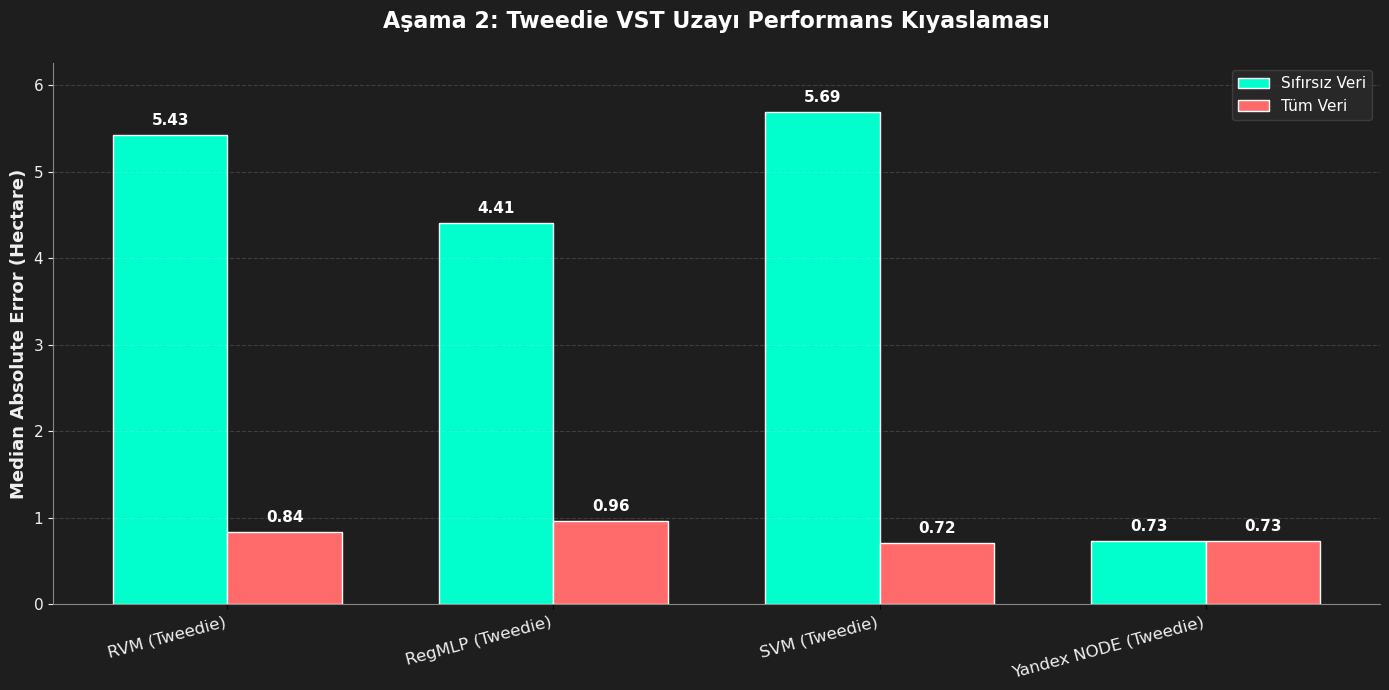

In [21]:
from sklearn.compose import TransformedTargetRegressor

def to_tweedie(y_log):
    y_orig = np.expm1(y_log)
    y_tw = 4.0 * (y_orig ** 0.25)
    return y_tw

def from_tweedie(y_tw):
    y_tw_clipped = np.clip(y_tw, 0, None)
    y_orig = (y_tw_clipped / 4.0) ** 4
    return np.log1p(y_orig)

stage2_models = {
    'SVM (Tweedie)': {
        'model': lambda **kwargs: TransformedTargetRegressor(
            regressor=SVR(kernel='rbf', **kwargs),
            func=to_tweedie,
            inverse_func=from_tweedie,
            check_inverse=False
        ),
        'objective': None 
    },
    'RVM (Tweedie)': {
        'model': lambda **kwargs: TransformedTargetRegressor(
            regressor=RVR(kernel='rbf', n_iter=150, tol=1e-2, **kwargs),
            func=to_tweedie,
            inverse_func=from_tweedie,
            check_inverse=False
        ),
        'objective': None 
    },
    'RegMLP (Tweedie)': {
        'model': lambda **kwargs: TransformedTargetRegressor(
            regressor=PyTorchMLPWrapper(**kwargs),
            func=to_tweedie,
            inverse_func=from_tweedie,
            check_inverse=False
        ),
        'objective': None 
    },
    'Yandex NODE (Tweedie)': {
        'model': lambda **kwargs: TransformedTargetRegressor(
            regressor=make_pipeline(StandardScaler(), PyTorchTabularWrapper(model_name='node', **kwargs)),
            func=to_tweedie,
            inverse_func=from_tweedie,
            check_inverse=False
        ),
        'objective': None 
    }
}

stage2_results = evaluate_model_family(
    family_name="Aşama 2: Tweedie VST Uzayı", 
    models_dict=stage2_models, 
    datasets=datasets_dict, 
    X_tst=X_test, 
    y_tst=y_test
)

## HÜCRE 5: AŞAMA 3 - GAMMA UZAYI 


Final Evaluation Complete: Aşama 3: Gamma VST Uzayı
--------------------------------------------------------------------------------



,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,SVM (Gamma),Sıfırsız Veri,Default,5.5904,21.4610,109.3470,-0.2997,-0.0792,6.0190
1,RVM (Gamma),Sıfırsız Veri,Default,6.6117,21.7420,109.1036,-0.3667,-0.0692,6.9615
2,RegMLP (Gamma),Sıfırsız Veri,Default,22.4289,38.9280,112.7901,-1.9783,0.0618,29.1863


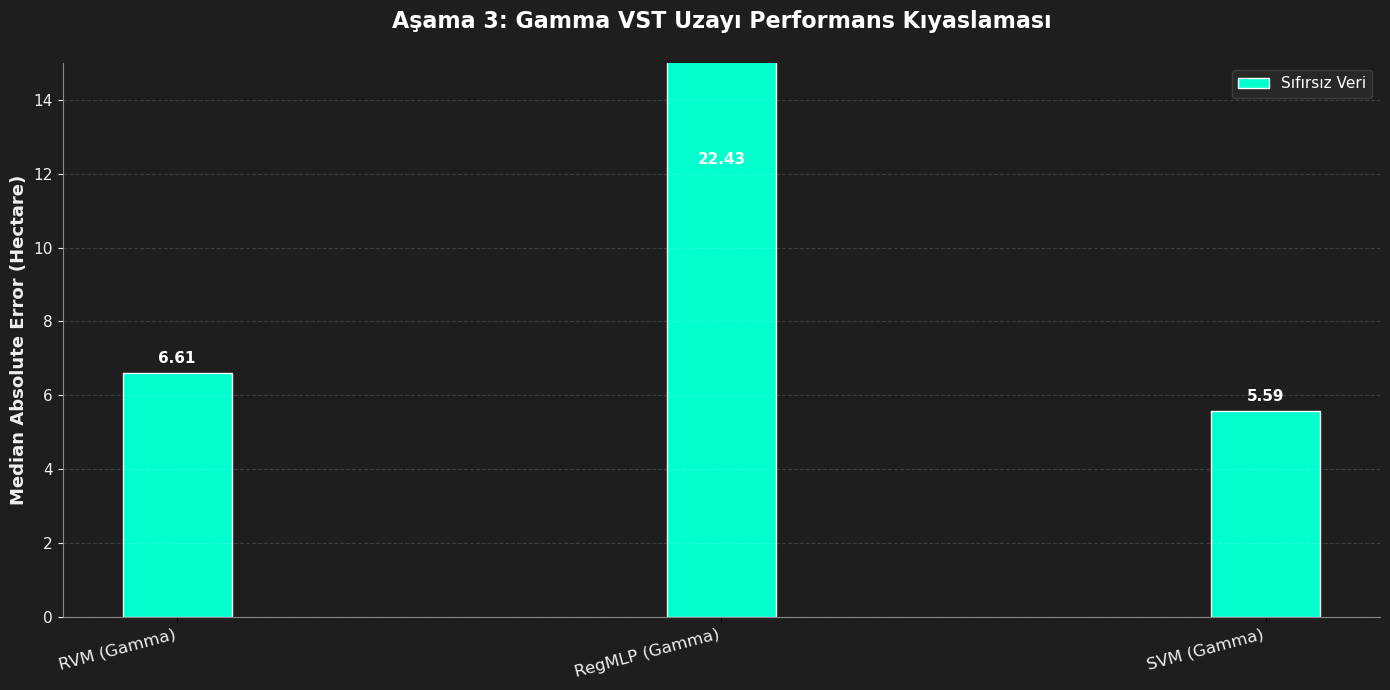

In [22]:
from sklearn.compose import TransformedTargetRegressor

def to_gamma(y_log1p):
    y_orig = np.expm1(y_log1p)
    return np.log(y_orig)

def from_gamma(y_gamma):
    y_orig = np.exp(y_gamma)
    return np.log1p(y_orig)

stage3_models = {
    'SVM (Gamma)': {
        'model': lambda **kwargs: TransformedTargetRegressor(
            regressor=SVR(kernel='rbf', **kwargs),
            func=to_gamma,
            inverse_func=from_gamma,
            check_inverse=False
        ),
        'objective': None 
    },
    'RVM (Gamma)': {
        'model': lambda **kwargs: TransformedTargetRegressor(
            regressor=RVR(kernel='rbf', n_iter=150, tol=1e-2, **kwargs),
            func=to_gamma,
            inverse_func=from_gamma,
            check_inverse=False
        ),
        'objective': None 
    },
    'RegMLP (Gamma)': {
        'model': lambda **kwargs: TransformedTargetRegressor(
            regressor=PyTorchMLPWrapper(**kwargs),
            func=to_gamma,
            inverse_func=from_gamma,
            check_inverse=False
        ),
        'objective': None 
    },
    'Yandex NODE (Gamma)': {
        'model': lambda **kwargs: TransformedTargetRegressor(
            regressor=make_pipeline(StandardScaler(), PyTorchTabularWrapper(model_name='node', **kwargs)),
            func=to_gamma,
            inverse_func=from_gamma,
            check_inverse=False
        ),
        'objective': None 
    }
}

gamma_datasets = {
    "Sıfırsız Veri": datasets_dict["Sıfırsız Veri"]
}

stage3_results = evaluate_model_family(
    family_name="Aşama 3: Gamma VST Uzayı", 
    models_dict=stage3_models, 
    datasets=gamma_datasets, 
    X_tst=X_test, 
    y_tst=y_test
)

# Feature Engineerin 2:

In [24]:
import pandas as pd
import numpy as np
import glob
import os

data_dir = '../../data/processed/'
csv_files = glob.glob(os.path.join(data_dir, '*.csv'))

def transform_log_to_tweedie(y_log):
    y_orig = np.expm1(y_log)
    return 4.0 * (y_orig ** 0.25)

for file in csv_files:
    df = pd.read_csv(file)
    modified = False
    
    if 'area' in df.columns:
        df['area'] = transform_log_to_tweedie(df['area'])
        modified = True
    elif len(df.columns) == 1 and 'y_' in os.path.basename(file).lower():
        col_name = df.columns[0]
        df[col_name] = transform_log_to_tweedie(df[col_name])
        modified = True
        
    if modified:
        df.to_csv(file, index=False)